Proiectul meu constă în identificarea artistului unei picturi la prima vedere prin intermediul CNN-urilor. Am ales să folosesc modelul ResNet18 pre-antrenat pe ImageNet și să îl adaptez cerinței mele folosind transfer learning.

#Încarcarea fișierului json

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 67 bytes


#Încarcarea dataset-ului
Link: https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time




In [ ]:
!pip install kaggle
!kaggle datasets download -d ikarus777/best-artworks-of-all-time

!unzip -q best-artworks-of-all-time.zip -d artworks

Dataset URL: https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time
License(s): CC-BY-NC-SA-4.0
100% 2.29G/2.29G [01:45<00:00, 21.5MB/s]
100% 2.29G/2.29G [01:45<00:00, 23.3MB/s]


am șters 2 foldere cu nume corupte

In [ ]:
import shutil

shutil.rmtree('/content/artworks/images/images/Albrecht_DuтХа├кrer', ignore_errors=True)
shutil.rmtree('/content/artworks/images/images/Albrecht_Du╠Иrer', ignore_errors=True)

verificare

In [ ]:
import os

base_path = '/content/artworks/images/images'
artists = os.listdir(base_path)
print(f"Numar de artisti: {len(artists)}")
print("Cativa artisti:", artists[:5])


Numar de artisti: 49
Cativa artisti: ['Gustav_Klimt', 'Marc_Chagall', 'Henri_Matisse', 'Michelangelo', 'Pieter_Bruegel']


#Împarțirea in imagini de train/test (80% training, 20% test)


In [ ]:
import random
from tqdm import tqdm  # Bara de progres

source_dir = '/content/artworks/images/images'
target_dir = '/content/split_data'
train_dir = os.path.join(target_dir, 'train')
test_dir = os.path.join(target_dir, 'test')

# Crearea folderelor de output
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# random.seed pentru repartizarea aleatoare a imaginilor
random.seed(42)

# Se parcurg toti artistii
for artist in tqdm(os.listdir(source_dir)):
    artist_path = os.path.join(source_dir, artist)
    if not os.path.isdir(artist_path):
        continue

    images = os.listdir(artist_path)
    random.shuffle(images) # Se amesteca imaginile

    split_idx = int(0.8 * len(images))
    train_images = images[:split_idx]
    test_images = images[split_idx:]

    # Se creeaza folderele fiecarui artist in split_data
    os.makedirs(os.path.join(train_dir, artist), exist_ok=True)
    os.makedirs(os.path.join(test_dir, artist), exist_ok=True)

    # Se copiaza imaginile
    for img in train_images:
        src = os.path.join(artist_path, img)
        dst = os.path.join(train_dir, artist, img)
        shutil.copyfile(src, dst)

    for img in test_images:
        src = os.path.join(artist_path, img)
        dst = os.path.join(test_dir, artist, img)
        shutil.copyfile(src, dst)

print("Split complet")


100%|██████████| 49/49 [00:08<00:00,  5.82it/s]

Split complet


#Definirea transformărilor și a DataLoader-elor

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Transformari pentru ResNet18
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # redimensionare pentru ResNet18
    transforms.ToTensor(),          # imagine -> tensor
    transforms.Normalize(           # normalizare cu valorile din ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_path = '/content/split_data/train'
test_path = '/content/split_data/test'

# Se creeaza dataset-urile
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Se creeaza dataloader-ele
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


Verificare

Numar de clase (artisti): 49
Exemple in train: 6473
Exemple in test: 1645


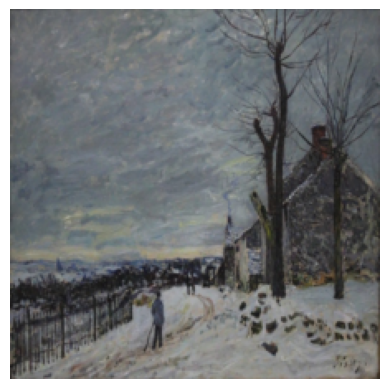

Artist: Alfred_Sisley


In [ ]:
# Numar de clase si exemple
print(f"Numar de clase (artisti): {len(train_dataset.classes)}")
print(f"Exemple in train: {len(train_dataset)}")
print(f"Exemple in test: {len(test_dataset)}")


def show_image(img_tensor):
  # Modificam imaginea astfel incat sa poata fi afisata (tensor->array)
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Afisam prima imagine din dataset
img, label = train_dataset[0]
show_image(img)
print("Artist:", train_dataset.classes[label])


#Definirea și modificarea modelului ResNet18

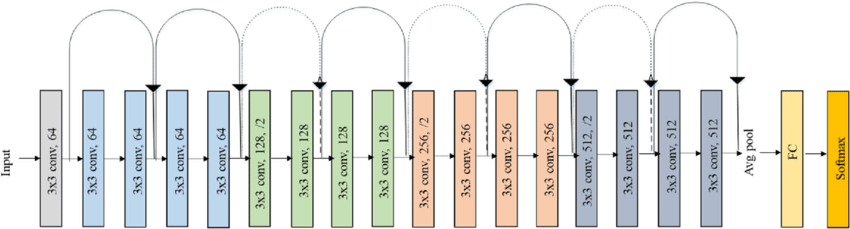

In [ ]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Incarcam modelul resnet18 pre-antrenat
model = models.resnet18(pretrained=True)

# Modificam ultimul strat astfel incat sa aiba ca nr de output-uri nr de artisti
num_artists = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_artists)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#Antrenarea modelului

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        # Trecerea pe cuda
        images = images.to(device)
        labels = labels.to(device)

        # Curatam gradientii de la iteratia precedenta
        optimizer.zero_grad()
        # Aplicam reteaua neurala pe imaginile din batch-ul curent => predictie
        outputs = model(images)
        # Calculam cat de gresita este predictia
        loss = loss_fn(outputs, labels)
        # Aplicam algoritmul de back-propagation
        loss.backward()
        # Actualizam greutatile modelului
        optimizer.step()

        #Actualizam loss-ul
        running_loss += loss.item()

    # Media loss-ului pe fiecare batch al epocii
    avg_loss = running_loss / len(train_loader)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():  #nu mai calculam gradient
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1) #obtinem clasa prezisa (cea cu probabilitatea cea mai mare)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total * 100

    print(f"[{epoch+1}/{epochs}] Loss: {avg_loss:.4f} | Acuratete: {accuracy:.2f}%")


[1/10] Loss: 2.1163 | Acuratete: 66.87%
[2/10] Loss: 0.8643 | Acuratete: 70.94%
[3/10] Loss: 0.3682 | Acuratete: 77.14%
[4/10] Loss: 0.1367 | Acuratete: 77.93%
[5/10] Loss: 0.0583 | Acuratete: 78.54%
[6/10] Loss: 0.0325 | Acuratete: 77.69%
[7/10] Loss: 0.0177 | Acuratete: 78.84%
[8/10] Loss: 0.0141 | Acuratete: 77.57%
[9/10] Loss: 0.0131 | Acuratete: 78.36%
[10/10] Loss: 0.0087 | Acuratete: 78.97%


#Salvarea modelului

In [ ]:
# Salvare
torch.save(model.state_dict(), "resnet_artist.pt")

#Predicție pe imagini noi

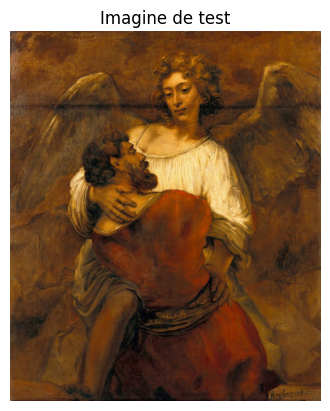

Artist prezis: Rembrandt


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# daca s-a inchis colab intre timp
# model.load_state_dict(torch.load("resnet_artist.pt"))
# model.eval()

# Incarcarea unei imagini noi
img_path = "/content/split_data/test/Rembrandt/Rembrandt_15.jpg"
img = Image.open(img_path).convert("RGB")

# Afisarea imaginii
plt.imshow(img)
plt.axis("off")
plt.title("Imagine de test")
plt.show()

# Aplicam aceleasi transformari ca la train
img_tensor = transform(img).unsqueeze(0).to(device)  # [1, 3, 224, 224]

# Predictie
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    predicted_class = torch.argmax(output, 1).item()
    predicted_artist = train_dataset.classes[predicted_class]

print(f"Artist prezis: {predicted_artist}")
